<h2>Univariate Imputation</h2>

This involves filling missing values based only on the statistics of that specific column.

<h3>Numeric Features</h3>

- Mean/Median
- Random Value imputation
- End of Distribution Imputation

In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.DataFrame({"Age":[20,21,22,23,24,25,100,np.nan,np.nan,22]})

In [4]:
df['Age'].mean()

32.125

In [ ]:
df['Age_mean'] = df['Age'].fillna(df['Age'].mean())

In [6]:
df

,Age,Age_mean
0,20.0,20.000
1,21.0,21.000
2,22.0,22.000
3,23.0,23.000
4,24.0,24.000
5,25.0,25.000
6,100.0,100.000
7,NaN,32.125
8,NaN,32.125
9,22.0,22.000


In [7]:
np.random.seed(42)

data = {
    'Age':np.random.normal(30,10,1000).tolist(),
    'Salary':np.random.exponential(50000,1000).tolist()
}
df = pd.DataFrame(data)

In [8]:
df.head()

,Age,Salary
0,34.967142,9165.056757
1,28.617357,5522.440864
2,36.476885,50589.205735
3,45.230299,61289.746976
4,27.658466,1604.787337


In [11]:
df.columns

Index(['Age', 'Salary'], dtype='str')

In [9]:
for col in df.columns:
    df.loc[df.sample(frac=0.1).index,col] = np.nan

In [14]:
df.isnull().sum()

Age       100
Salary    100
dtype: int64

In [15]:
mean_imputer = SimpleImputer(strategy='mean')

df['Age_mean'] = mean_imputer.fit_transform(df[['Age']])

In [16]:
df.head()

,Age,Salary,Age_mean
0,34.967142,9165.056757,34.967142
1,NaN,5522.440864,30.165083
2,36.476885,50589.205735,36.476885
3,45.230299,61289.746976,45.230299
4,27.658466,1604.787337,27.658466


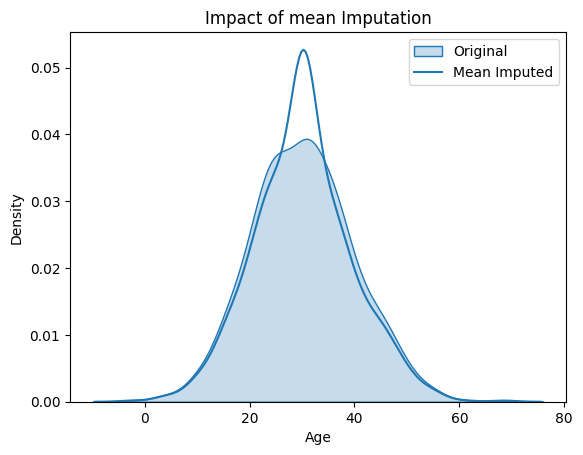

In [17]:
sns.kdeplot(df['Age'],label='Original',fill=True)
sns.kdeplot(df['Age_mean'],label='Mean Imputed')
plt.legend()
plt.title("Impact of mean Imputation")
plt.show()

In [18]:
median_imputer = SimpleImputer(strategy='median')

df['Salary_median'] = mean_imputer.fit_transform(df[['Salary']])

Random value imputation

In [29]:
def random_value_imputation(series):
    data = series.copy()
    random_samples = data.dropna().sample(data.isnull().sum(),random_state=42)
    random_samples.index = data[data.isnull()].index
    data.loc[data.isnull()] = random_samples
    return data

df['Age_random'] = random_value_imputation(df['Age'])

In [30]:
df.tail(20)

,Age,Salary,Age_mean,Salary_median,Age_random
980,37.858002,68049.641318,37.858002,68049.641318,37.858002
981,34.254576,35287.924443,34.254576,35287.924443,34.254576
982,20.330239,NaN,20.330239,49277.386695,20.330239
983,29.522886,3678.678925,29.522886,3678.678925,29.522886
984,NaN,14677.736194,30.165083,14677.736194,27.803281
985,18.416353,22459.338035,18.416353,22459.338035,18.416353
986,45.033983,31979.690828,45.033983,31979.690828,45.033983
987,38.773623,2336.174200,38.773623,2336.174200,38.773623
988,27.790358,7542.545527,27.790358,7542.545527,27.790358
989,30.268858,16204.462705,30.268858,16204.462705,30.268858


<h3>End of distribution imputation</h3>

In [31]:
extreme_val = df['Age'].mean() + 3 * df['Age'].std()
extreme_val

59.412597985626135

In [32]:
df['Age_EndDist'] = df['Age'].fillna(extreme_val)

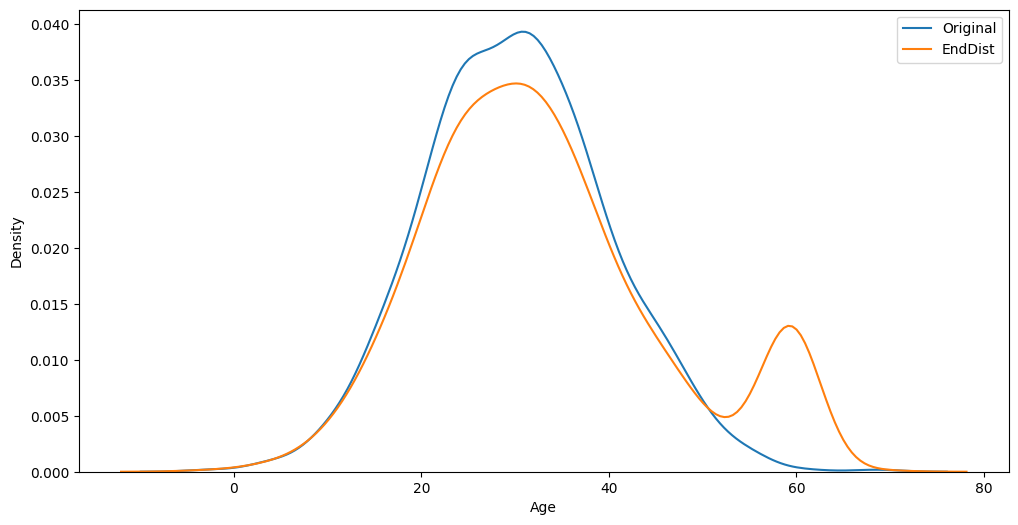

In [34]:
plt.figure(figsize=(12,6))
sns.kdeplot(df['Age'],label='Original')
sns.kdeplot(df['Age_EndDist'],label='EndDist')
plt.legend()
plt.show()